# bagpipe DB review

Exploratory only — no outputs committed (nbstripout). Reads the shared
brainlink.db via bagpipe's config, no paths/data hardcoded here.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bagpipe.core.config import get_path

sns.set_theme(style="whitegrid")
con = sqlite3.connect(get_path("db_path"))

## 1. Table overview

In [2]:
tables = pd.read_sql("select name from sqlite_master where type='table'", con)["name"]
counts = {t: pd.read_sql(f"select count(*) c from {t}", con)["c"][0] for t in tables}
pd.Series(counts, name="rows").sort_values(ascending=False).to_frame()

,rows
features,9194387
validation_log,116374
session,10298
participant_session_map,10180
imaging_path,9306
legacy_participant,7255
predictions,6712
questionnaire_response,6380
cat12_quality,6350
participant,5722


## 2. SNBB cohort (S####)

In [3]:
snbb = pd.read_sql('''
    select s.session_id, s.uid, s.lab, s.scan_date, s.mapping_complete,
           d.age_at_scan, d.sex
    from session s
    left join demographics d on d.session_id = s.session_id
    where s.uid is not null
''', con, parse_dates=["scan_date"])
print(len(snbb), "sessions,", snbb["uid"].nunique(), "subjects")
snbb.head()

10180 sessions, 5722 subjects


,session_id,uid,lab,scan_date,mapping_complete,age_at_scan,sex
0,202603241150,S583614,,2026-03-24,0,NaN,None
1,202604151211,S411912,,2026-04-15,0,NaN,None
2,202601291929,S424695,,2026-01-29,0,NaN,None
3,202602221200,S056456,,2026-02-22,0,NaN,None
4,202012061756,S004192,YA,2020-12-06,1,25.42,Female


In [4]:
snbb[snbb["session_id"] == "202604121409"]

,session_id,uid,lab,scan_date,mapping_complete,age_at_scan,sex
4399,202604121409,S956416,YA,2026-04-12,1,33.065024,Male


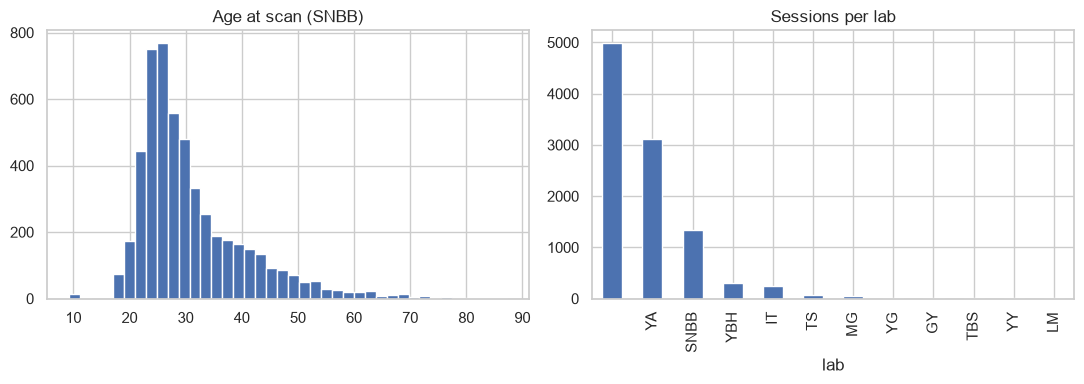

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
snbb["age_at_scan"].dropna().hist(bins=40, ax=axes[0])
axes[0].set_title("Age at scan (SNBB)")
snbb["lab"].value_counts().plot.bar(ax=axes[1])
axes[1].set_title("Sessions per lab")
plt.tight_layout()

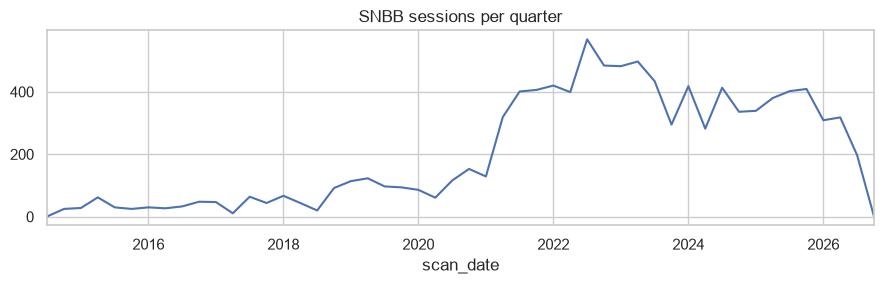

In [5]:
snbb.set_index("scan_date").resample("QE").size().plot(figsize=(9, 3), title="SNBB sessions per quarter")
plt.tight_layout()

In [6]:
missing = pd.Series({
    "no age": snbb["age_at_scan"].isna().mean(),
    "no sex": snbb["sex"].isna().mean(),
    "mapping incomplete": (~snbb["mapping_complete"].astype(bool)).mean(),
})
(missing * 100).round(1).to_frame("pct missing")

,pct missing
no age,49.0
no sex,49.0
mapping incomplete,48.9


## 3. Legacy cohort (pre-SNBB, 12-digit ids)

In [7]:
legacy = pd.read_sql("select * from legacy_participant", con, parse_dates=["scan_date"])
print(len(legacy), "rows")
legacy.head()

7255 rows


,subject_id,lab,gender,age_at_scan,weight,height,scan_date,study,group_label,scan_tag,subject_code,ingested_at
0,200109071247,YA,Female,57.0,60.0,NaN,2001-09-07,ADVD,H,None,None,2026-08-19 08:57:14
1,200110171735,YA,Female,76.0,68.0,NaN,2001-10-17,ADVD,VAD,None,None,2026-08-19 08:57:14
2,200112071234,YA,Male,79.0,69.0,NaN,2001-12-07,ADVD,AD,None,None,2026-08-19 08:57:14
3,200201181249,YA,Male,58.0,69.0,NaN,2002-01-18,ADVD,AD,None,None,2026-08-19 08:57:14
4,200207171551,YA,Male,77.0,80.0,NaN,2002-07-17,ADVD,AD,None,None,2026-08-19 08:57:14


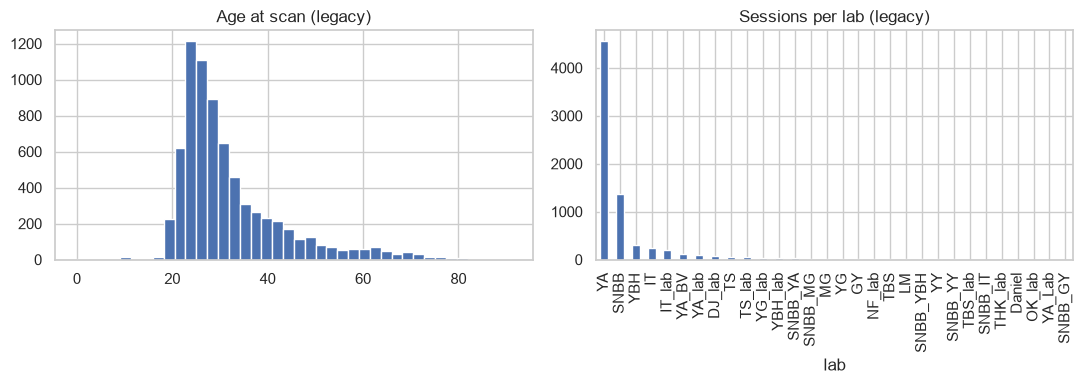

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
legacy["age_at_scan"].dropna().hist(bins=40, ax=axes[0])
axes[0].set_title("Age at scan (legacy)")
legacy["lab"].value_counts().plot.bar(ax=axes[1])
axes[1].set_title("Sessions per lab (legacy)")
plt.tight_layout()

## 4. CAT12 tabular features (`features` table)

Long format: one row per (subject, session, atlas, region, metric).

In [9]:
feat_summary = pd.read_sql('''
    select source, atlas, metric, count(*) n, avg(value) mean_value
    from features group by source, atlas, metric order by n desc
''', con)
feat_summary

,source,atlas,metric,n,mean_value
0,cat12,Schaefer2018N400n7Tian2020S2,vol_csf,2483136,0.311140
1,cat12,Schaefer2018N400n7Tian2020S2,vol_gm,2483136,1.252300
2,cat12,Schaefer2018N400n7Tian2020S2,vol_wm,2483136,0.415526
3,cat12_v26,Schaefer2018N400n7Tian2020S2,vol_csf,203040,0.319820
4,cat12_v26,Schaefer2018N400n7Tian2020S2,vol_gm,203040,1.171147
5,cat12_v26,Schaefer2018N400n7Tian2020S2,vol_wm,203040,0.393155
6,cat12_v26,surf_Schaefer2018N400n7,thickness,116800,2.669431
7,cat12_v26,surf_Destrieux,thickness,43800,2.694874
8,cat12_v26,surf_DK40,thickness,20148,2.710738
9,cat12,,TIV,5748,1419.069855


In [10]:
globals_df = pd.read_sql('''
    select subject_key, session_id, metric, value
    from features where region = 'global'
''', con)
globals_wide = globals_df.pivot_table(index=["subject_key", "session_id"], columns="metric", values="value")
globals_wide.describe()

metric,TIV,vol_csf,vol_gm,vol_wm,vol_wmh
count,5774.000000,5774.000000,5774.000000,5774.000000,5774.0
mean,1418.708377,249.325481,665.333650,504.049246,0.0
std,151.904422,61.227624,74.503941,68.245632,0.0
min,71.403004,16.722337,0.415148,3.484633,0.0
25%,1318.011952,207.758210,620.440848,462.602780,0.0
50%,1421.505177,240.413371,665.974932,503.746305,0.0
75%,1514.863144,280.446061,711.720091,546.609297,0.0
max,1946.713170,661.514328,1008.760018,1184.911980,0.0


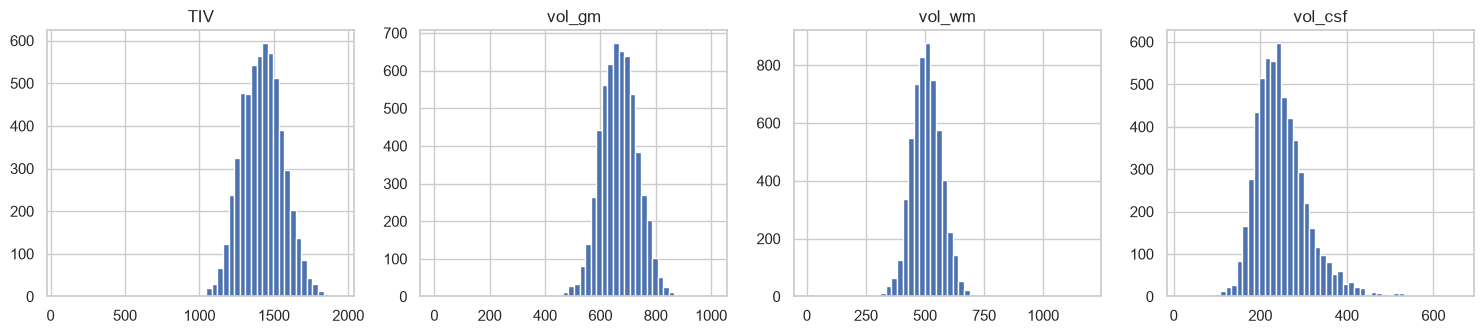

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, col in zip(axes, ["TIV", "vol_gm", "vol_wm", "vol_csf"]):
    globals_wide[col].hist(bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()

### Age vs. global GM volume — sanity check for a brain-age signal

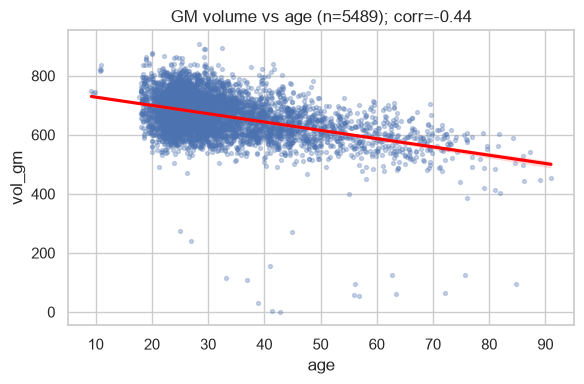

In [12]:
age_snbb = snbb.set_index(["uid", "session_id"])["age_at_scan"]
age_legacy = legacy.set_index("subject_id")["age_at_scan"]

gm = globals_wide["vol_gm"].reset_index()
gm["age"] = gm.apply(
    lambda r: age_snbb.get((r["subject_key"], r["session_id"]), age_legacy.get(r["subject_key"])),
    axis=1,
)
gm = gm.dropna(subset=["age"])
plt.figure(figsize=(6, 4))
sns.regplot(data=gm, x="age", y="vol_gm", scatter_kws={"s": 8, "alpha": 0.3}, line_kws={"color": "red"})
plt.title(f"GM volume vs age (n={len(gm)}); corr={gm['age'].corr(gm['vol_gm']):.2f}")
plt.tight_layout()

## 5. Imaging paths (for DL training)

In [13]:
img_snbb = pd.read_sql("select processing_stream, count(*) n from imaging_path group by processing_stream", con)
img_legacy = pd.read_sql("select processing_stream, count(*) n from legacy_imaging_path group by processing_stream", con)
print("SNBB:\n", img_snbb, "\n\nLegacy:\n", img_legacy)

SNBB:
   processing_stream     n
0              mwp1  4653
1                wm  4653 

Legacy:
   processing_stream     n
0              mwp1  1104
1                wm  1104


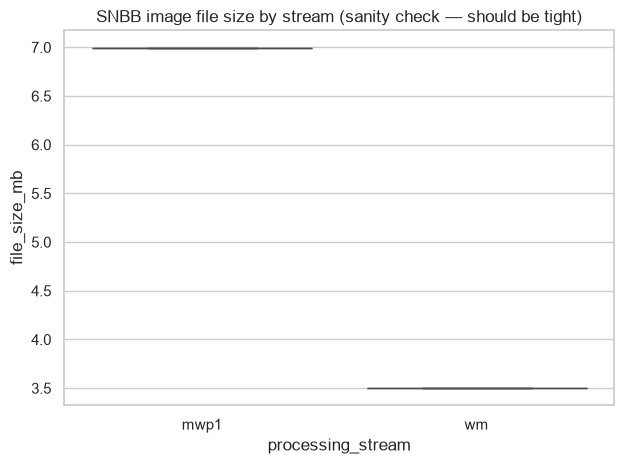

In [14]:
sizes = pd.read_sql("select processing_stream, file_size_bytes from imaging_path", con)
sizes["file_size_mb"] = sizes["file_size_bytes"] / 1e6
sns.boxplot(data=sizes, x="processing_stream", y="file_size_mb")
plt.title("SNBB image file size by stream (sanity check — should be tight)")
plt.tight_layout()

## 6. Coverage: sessions with features vs. images vs. demographics

In [15]:
cov = pd.read_sql('''
    select s.uid, s.session_id,
           d.session_id is not null as has_demo,
           f.session_id is not null as has_features,
           ip.session_id is not null as has_image
    from session s
    left join demographics d on d.session_id = s.session_id
    left join (select distinct session_id from features) f on f.session_id = s.session_id
    left join (select distinct session_id from imaging_path) ip on ip.session_id = s.session_id
    where s.uid is not null
''', con)
cov[["has_demo", "has_features", "has_image"]].mean().mul(100).round(1).to_frame("pct of SNBB sessions")

,pct of SNBB sessions
has_demo,51.1
has_features,48.3
has_image,45.7


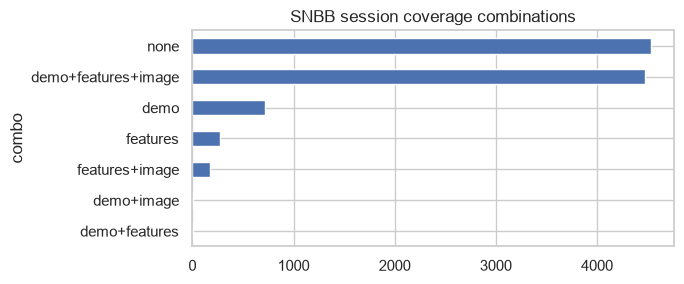

In [16]:
combo = cov.groupby(["has_demo", "has_features", "has_image"]).size().rename("n").reset_index()
combo["combo"] = combo.apply(
    lambda r: "+".join(
        n for n, has in zip(["demo", "features", "image"], [r.has_demo, r.has_features, r.has_image]) if has
    ) or "none", axis=1,
)
combo.set_index("combo")["n"].sort_values().plot.barh(figsize=(7, 3), title="SNBB session coverage combinations")
plt.tight_layout()

## 7. Validation issues logged by brainlink ingestion

In [17]:
val = pd.read_sql("select level, entity_type, check_name, count(*) n from validation_log group by 1,2,3 order by n desc limit 30", con)
val

,level,entity_type,check_name,n
0,warning,session,incomplete_mapping,60659
1,info,questionnaire_response,questionnaire_version_no,31351
2,warning,questionnaire_response,duplicate_subject_in_questionnaire,20522
3,warning,questionnaire_response,orphan_questionnaire_subject,3693
4,warning,session,missing_demographics_fields,95
5,warning,session,missing_questionnaire,54


## 8. Training tables (`bag export training-table`)

Three Parquet tables, all keyed by (subject_key, session_id):
- `globals.parquet` — wide, tabular model input
- `regional.parquet` — long, per-region base-learner input (stacked ensemble)
- `image_paths.parquet` — CNN input

In [18]:
from bagpipe.core.config import get_path

ds_dir = get_path("datasets_dir")
globals_df = pd.read_parquet(ds_dir / "globals.parquet")
regional_df = pd.read_parquet(ds_dir / "regional.parquet")
paths_df = pd.read_parquet(ds_dir / "image_paths.parquet")
for name, df in [("globals", globals_df), ("regional", regional_df), ("image_paths", paths_df)]:
    print(name, df.shape)

globals (5664, 11)
regional (7877033, 7)
image_paths (5653, 5)


### 8.1 Globals

In [19]:
globals_df.describe(include="all")

,subject_key,session_id,cohort,lab,age,sex,TIV,vol_gm,vol_wm,vol_csf,vol_wmh
count,5664,5664,5664,5664,5483.000000,5474,5664.000000,5664.000000,5664.000000,5664.000000,5664.0
unique,4479,5639,2,13,NaN,2,NaN,NaN,NaN,NaN,NaN
top,S956416,201807301433,snbb,YA,NaN,Male,NaN,NaN,NaN,NaN,NaN
freq,15,2,4649,3721,NaN,3134,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,32.188560,NaN,1421.004347,665.748052,505.156346,250.099949,0.0
std,NaN,NaN,NaN,NaN,11.250986,NaN,148.266156,72.231989,65.924477,60.679108,0.0
min,NaN,NaN,NaN,NaN,9.234771,NaN,71.403004,0.415148,3.484633,16.722337,0.0
25%,NaN,NaN,NaN,NaN,24.663929,NaN,1320.253885,620.938337,463.663430,208.417558,0.0
50%,NaN,NaN,NaN,NaN,28.500000,NaN,1423.077013,666.212439,504.150577,240.910182,0.0
75%,NaN,NaN,NaN,NaN,36.304689,NaN,1515.635408,711.573157,546.670744,280.587581,0.0


In [20]:
globals_df.isna().mean().mul(100).round(1).to_frame("pct missing")

,pct missing
subject_key,0.0
session_id,0.0
cohort,0.0
lab,0.0
age,3.2
sex,3.4
TIV,0.0
vol_gm,0.0
vol_wm,0.0
vol_csf,0.0


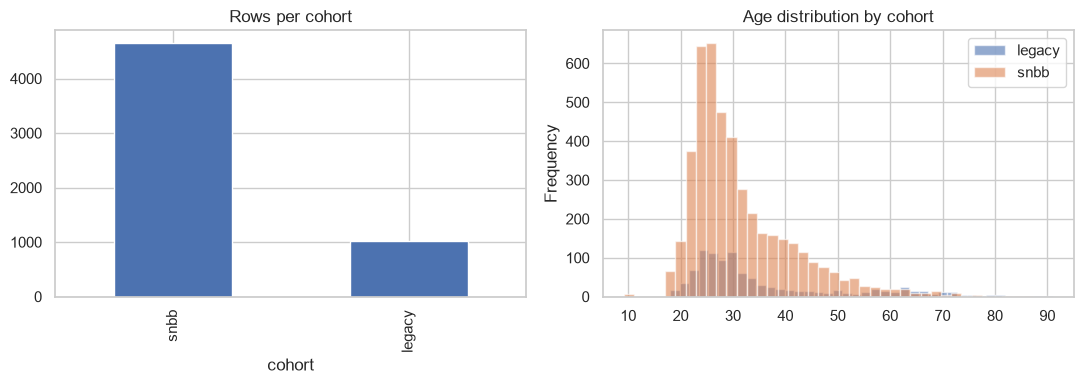

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
globals_df["cohort"].value_counts().plot.bar(ax=axes[0], title="Rows per cohort")
globals_df.groupby("cohort")["age"].plot.hist(bins=40, alpha=0.6, ax=axes[1], legend=True)
axes[1].set_title("Age distribution by cohort")
plt.tight_layout()

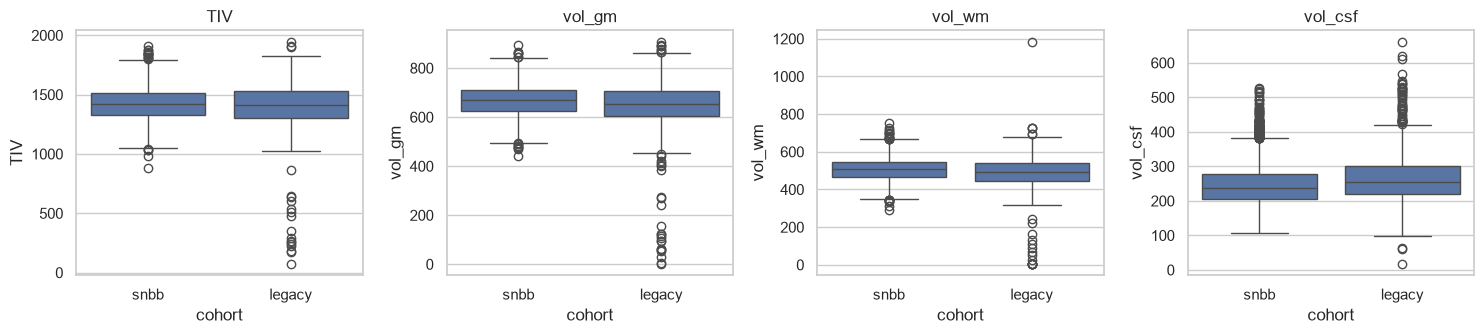

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, col in zip(axes, ["TIV", "vol_gm", "vol_wm", "vol_csf"]):
    sns.boxplot(data=globals_df, x="cohort", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()

Outlier check — TIV should never be near zero:

In [23]:
globals_df.nsmallest(10, "TIV")[["subject_key", "session_id", "cohort", "age", "TIV", "vol_gm"]]

,subject_key,session_id,cohort,age,TIV,vol_gm
5511,201704090945,201704090945,legacy,41.42,71.403004,3.603004
5305,201505041535,201505041535,legacy,42.82,175.340661,0.415148
5222,201401270820,201401270820,legacy,33.22,180.985048,116.101886
4958,200905011225,200905011225,legacy,63.51,227.081311,61.254049
4986,200908041758,200908041758,legacy,56.03,245.041004,56.680239
4949,200903311153,200903311153,legacy,62.78,258.835497,125.058809
4922,200901201644,200901201644,legacy,56.17,262.937790,93.413551
4957,200904261142,200904261142,legacy,56.83,289.458976,55.008164
4931,200902021521,200902021521,legacy,72.19,347.529626,64.101081
4946,200903151339,200903151339,legacy,84.69,478.598997,95.433655


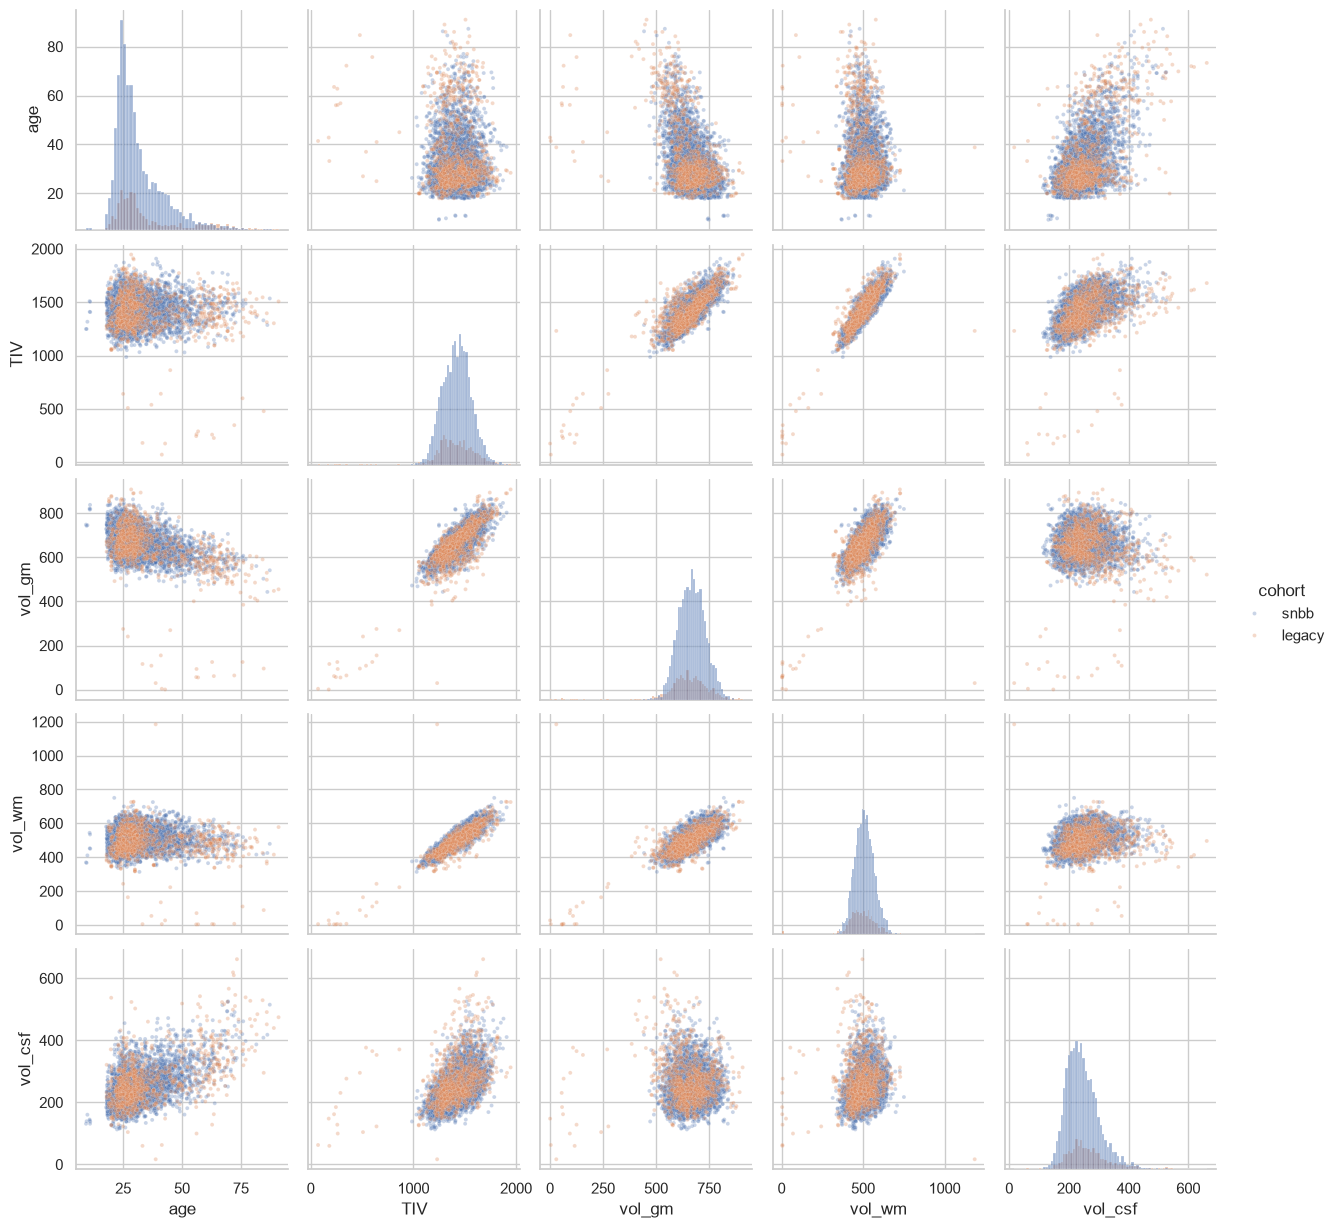

In [24]:
sns.pairplot(
    globals_df[["age", "TIV", "vol_gm", "vol_wm", "vol_csf", "cohort"]].dropna(),
    hue="cohort", plot_kws={"s": 8, "alpha": 0.3}, diag_kind="hist",
)

### 8.2 Regional (long)

In [25]:
print(regional_df[["atlas", "region", "metric"]].nunique())
regional_df.groupby("metric")["value"].describe()

atlas        4
region    1051
metric       4
dtype: int64


,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
thickness,125657.0,2.635546,0.531671,0.003161,2.412775,2.687423,2.928675,5.237263
vol_csf,2583792.0,0.313557,0.236356,0.000000,0.132095,0.272261,0.439329,3.298200
vol_gm,2583792.0,1.248305,0.635328,0.000000,0.781104,1.150155,1.598649,6.115984
vol_wm,2583792.0,0.415379,0.248361,0.000000,0.242060,0.366453,0.534225,4.449364


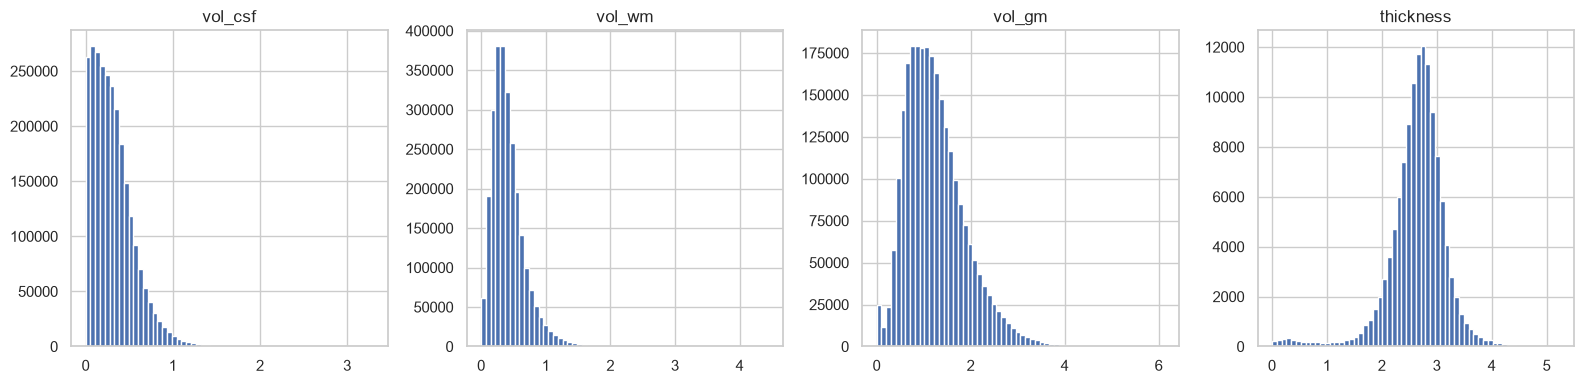

In [26]:
metrics = regional_df["metric"].unique()
fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
for ax, metric in zip(axes, metrics):
    regional_df.loc[regional_df.metric == metric, "value"].hist(bins=60, ax=ax)
    ax.set_title(metric)
plt.tight_layout()

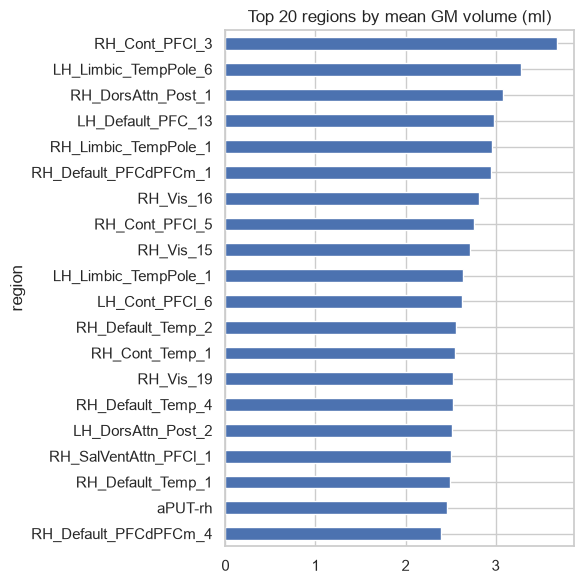

In [27]:
region_means = (
    regional_df[regional_df.metric == "vol_gm"]
    .groupby("region")["value"].mean().sort_values(ascending=False)
)
region_means.head(20).plot.barh(figsize=(6, 6), title="Top 20 regions by mean GM volume (ml)")
plt.gca().invert_yaxis()
plt.tight_layout()

In [28]:
sessions_per_region = regional_df.groupby("region").size()
print("regions:", len(sessions_per_region), "- rows/region range:", sessions_per_region.min(), "-", sessions_per_region.max())

regions: 1051 - rows/region range: 203 - 17943


### 8.2b Surface (thickness + full surfextract panel) — new in CAT26 reprocessing

Three surface atlases, ingested by `bag ingest cat12-cohort` whenever a session's
reprocessing had surface reconstruction enabled. Metric `thickness` on all three; since
2026-08-24, `gyrification`/`sulcal_depth`/`fractal_dimension` too (CAT12's own native
`catROIs_*.xml` output, `bagpipe.app.cat12_parse.SURFACE_METRIC_TAGS`), and
`surf_Schaefer2018N400n7` additionally gets `area`
(`bagpipe.app.surface_atlas.SURFACE_METRICS`) — see `docs/cat12_container_spec.md` §4d
for how these were wired (CAT12's `stools.surfextract` module, job 2 in
`container/cat12.def`) and `notebooks/surface_atlas_review.ipynb` §7 for a per-metric
breakdown. The cells below stay thickness-only to keep the histogram units comparable
(mm) across atlases — see the linked notebook for the other four metrics.

- `surf_DK40` / `surf_Destrieux` — CAT12's own native surface ROI output, parsed straight
  from `catROIs_*.xml`.
- `surf_Schaefer2018N400n7` — the production model's own 7-network Schaefer parcellation.
  **Not** from CAT12's own-atlas surface batch field (`output.sROImenu.satlases.ownatlas`)
  — a real single-subject test (2026-08-23) showed that field silently has no effect in
  this CAT26 build (see `docs/cat12_container_spec.md` §4b for the full investigation).
  Computed instead in Python, post-hoc, from CAT12's own native thickness + spherical
  registration output (`bagpipe.app.surface_atlas.custom_surface_regional`) — nearest-
  vertex resampling onto the atlas grid, same method CAT12's own surface-ROI code uses
  internally. **Validated against CAT12's own DK40 ground truth**: same method, run with
  CAT12's bundled DK40 `.annot` instead of the custom one, reproduces `catROIs_*.xml`'s
  real DK40 regional thickness to within 0.003mm (68 regions, one real subject).

**A join-coverage gap is expected and not a bug**: `regional.parquet` below inner-joins
onto `_cohorts()` (`session`/`legacy_participant`, for age/sex/cohort) — a surface-
processed session only shows up post-join once it's *also* tracked in one of those
cohort tables. The live cohort reprocessing job is still running and growing, so re-run
the cell below for current numbers rather than trusting any number written here.
`config/models/stacked_surface.yaml` is the opt-in stacked-ensemble config for once
coverage is enough to train on.

**For a closer look at the custom Schaefer atlas specifically** — region-level
distributions, hemisphere symmetry, comparison against the CAT12-native atlases, the
DK40 validation itself — see `notebooks/surface_atlas_review.ipynb`.

In [29]:
# n here is per (subject, session, atlas, metric) — more than one metric per atlas since
# 2026-08-24 (thickness plus gyrification/sulcal_depth/fractal_dimension/area), so group by
# metric too rather than reading "n" as a plain region count the way it used to be.
raw_surf = pd.read_sql('''
    select subject_key, session_id, atlas, metric, count(*) n
    from features where atlas like 'surf_%' group by subject_key, session_id, atlas, metric
''', con)
print("distinct surface-processed sessions:", raw_surf[["subject_key", "session_id"]].drop_duplicates().shape[0])
print(raw_surf.groupby(["atlas", "metric"])["n"].agg(["count", "mean"]))

n_sessions_total = regional_df[["subject_key", "session_id"]].drop_duplicates().shape[0]
surf_df = regional_df[regional_df["atlas"].str.startswith("surf_")]
n_sessions_surf = surf_df[["subject_key", "session_id"]].drop_duplicates().shape[0]
print(f"\nregional.parquet (post cohort-join): {n_sessions_surf}/{n_sessions_total} sessions "
      f"({n_sessions_surf / n_sessions_total:.1%})")

# why any gap: do these subject_keys exist in either cohort table at all?
missing = []
for sk in raw_surf["subject_key"].unique():
    in_session = pd.read_sql(f"select count(*) c from session where uid=\'{sk}\' or session_id=\'{sk}\'", con)["c"][0]
    in_legacy = pd.read_sql(f"select count(*) c from legacy_participant where subject_id=\'{sk}\'", con)["c"][0]
    if not (in_session or in_legacy):
        missing.append(sk)
print(f"{len(missing)}/{raw_surf['subject_key'].nunique()} surface-processed subjects have no cohort-demographics row yet (unmapped, out of bagpipe\'s scope)")


distinct surface-processed sessions: 292
                         count   mean
atlas                                
surf_DK40                  292   69.0
surf_Destrieux             292  150.0
surf_Schaefer2018N400n7    292  400.0

regional.parquet (post cohort-join): 203/5664 sessions (3.6%)
45/292 surface-processed subjects have no cohort-demographics row yet (unmapped, out of bagpipe's scope)


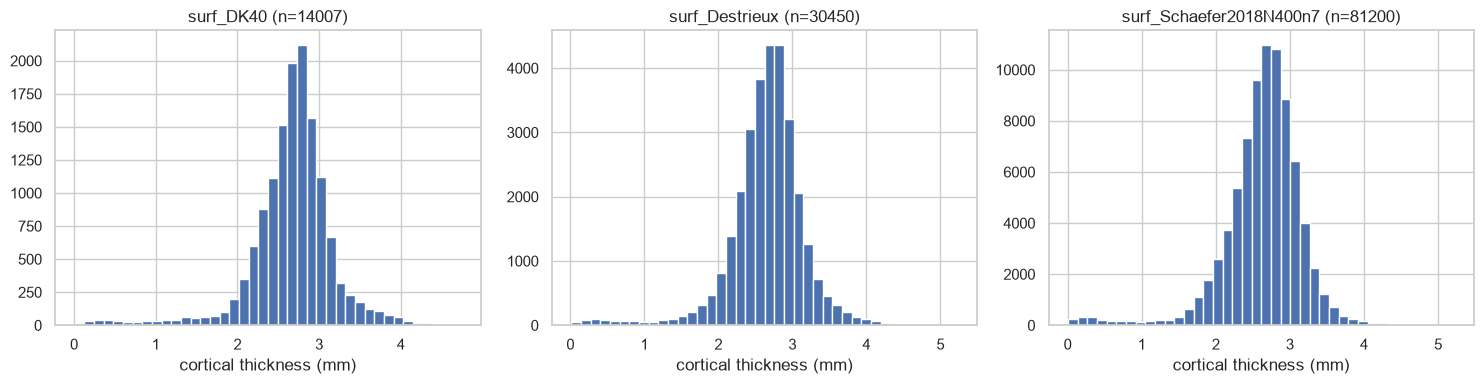

In [30]:
if n_sessions_surf:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, atlas in zip(axes, ["surf_DK40", "surf_Destrieux", "surf_Schaefer2018N400n7"]):
        vals = surf_df.loc[(surf_df["atlas"] == atlas) & (surf_df["metric"] == "thickness"), "value"]
        vals.hist(bins=40, ax=ax)
        ax.set_title(f"{atlas} (n={vals.shape[0]})")
        ax.set_xlabel("cortical thickness (mm)")
    plt.tight_layout()
else:
    print("no surface thickness ingested yet — nothing to plot")


### 8.3 Image paths

In [31]:
paths_df["cohort"].value_counts()

cohort
snbb      4653
legacy    1000
Name: count, dtype: int64

In [32]:
paths_df[["image_path_mwp1", "image_path_wm"]].notna().mean().mul(100).round(1).to_frame("pct present")

,pct present
image_path_mwp1,100.0
image_path_wm,100.0


### 8.4 Coverage across all three tables

In [33]:
key = globals_df[["subject_key", "session_id"]]
has_regional = key.merge(regional_df[["subject_key", "session_id"]].drop_duplicates(), how="left", indicator=True)["_merge"].eq("both")
has_image = key.merge(paths_df[["subject_key", "session_id"]], how="left", indicator=True)["_merge"].eq("both")
pd.Series({
    "globals row has regional data": has_regional.mean(),
    "globals row has image path": has_image.mean(),
}).mul(100).round(1).to_frame("pct")

,pct
globals row has regional data,100.0
globals row has image path,99.6
